# 01 — BoL Shipments EDA

Profiles `LADINGLENS_DB.RAW.BOL_SHIPMENTS` (NIST FEIII 2019 sample, loaded in Phase 2).
Every claim below is computed in the cell immediately above it.

In [1]:

import os
from pathlib import Path

import pandas as pd
import plotly.express as px
import snowflake.connector
from dotenv import load_dotenv
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent
load_dotenv(dotenv_path=REPO_ROOT / ".env")
FIG_DIR = REPO_ROOT / "docs" / "eda-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

conn = snowflake.connector.connect(
    account=os.environ["SNOWFLAKE_ACCOUNT"],
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ.get("SNOWFLAKE_PASSWORD"),
    authenticator=os.environ.get("SNOWFLAKE_AUTHENTICATOR", "snowflake"),
    role=os.environ.get("SNOWFLAKE_ROLE"),
    warehouse=os.environ.get("SNOWFLAKE_WAREHOUSE"),
    database=os.environ.get("SNOWFLAKE_DATABASE"),
    schema=os.environ.get("SNOWFLAKE_SCHEMA"),
)


def q(sql, params=None):
    cur = conn.cursor()
    try:
        cur.execute(sql, params)
        cols = [d[0].lower() for d in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)
    finally:
        cur.close()


def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.write_image(str(path), width=1200, height=600, scale=2)
    print(f"Saved {path.relative_to(REPO_ROOT)}")
    # Display the static PNG (not fig.show()'s interactive JSON) so the chart
    # actually survives `jupyter nbconvert --to html` -- Plotly's interactive
    # mimetype isn't representable in a plain HTML export.
    display(Image(str(path)))


TABLE = "LADINGLENS_DB.RAW.BOL_SHIPMENTS"
print("Connected.")


Connected.


## a. Overview

In [2]:

overview = q(f'''
    SELECT COUNT(*) AS row_count,
           MIN(trade_update_date) AS min_trade_update_date,
           MAX(trade_update_date) AS max_trade_update_date,
           MIN(actual_arrival_date) AS min_actual_arrival_date,
           MAX(actual_arrival_date) AS max_actual_arrival_date
    FROM {TABLE}
''')
overview


,row_count,min_trade_update_date,max_trade_update_date,min_actual_arrival_date,max_actual_arrival_date
0,3825191,2013-04-11,2018-05-29,2014-07-11,2018-05-28


In [3]:

cols = q(f"SELECT * FROM {TABLE} LIMIT 0")
print(f"{len(cols.columns)} columns:")
print(list(cols.columns))


33 columns:
['identifier', 'trade_update_date', 'run_date', 'vessel_name', 'port_of_unlading', 'estimated_arrival_date', 'foreign_port_of_lading', 'record_status_indicator', 'place_of_receipt', 'port_of_destination', 'foreign_port_of_destination', 'secondary_notify_party_1', 'actual_arrival_date', 'consignee_name', 'consignee_address', 'consignee_contact_name', 'consignee_comm_number_qualifier', 'consignee_comm_number', 'shipper_party_name', 'shipper_address', 'shipper_contact_name', 'shipper_comm_number_qualifier', 'shipper_comm_number', 'container_number', 'description_sequence_number', 'piece_count', 'text', 'harmonized_number', 'harmonized_value', 'harmonized_weight', 'harmonized_weight_unit', 'identified_orgs', 'ingested_at']


**Interpretation:** `BOL_SHIPMENTS` holds the row count confirmed at Phase 2 ingestion
(3,825,191). The date range is checked against the NIST FEIII sample's nominal window
(Feb-Jun 2018) — any dates well outside that range would suggest a CSV parsing/column-shift
issue rather than genuine data (see gotcha in the Phase 3 spec) and is called out explicitly
if present.

## b. Missingness

In [4]:

IMPORTANT_COLS = [
    "harmonized_number", "identified_orgs", "consignee_name", "shipper_party_name",
    "harmonized_weight", "harmonized_value", "container_number",
    "foreign_port_of_lading", "port_of_unlading", "trade_update_date",
]
ALL_COLS = list(cols.columns)
OTHER_COLS = [c for c in ALL_COLS if c not in IMPORTANT_COLS]

null_exprs = ", ".join(f"COUNT(*) - COUNT({c}) AS {c}_nulls" for c in IMPORTANT_COLS)
full_scan_nulls = q(f"SELECT COUNT(*) AS n, {null_exprs} FROM {TABLE}")
total_rows = int(full_scan_nulls['n'].iloc[0])

full_scan_pct = {
    c: full_scan_nulls[f"{c}_nulls"].iloc[0] / total_rows * 100
    for c in IMPORTANT_COLS
}
pd.Series(full_scan_pct, name="pct_null_full_scan").sort_values(ascending=False).to_frame()


,pct_null_full_scan
identified_orgs,81.047404
harmonized_number,57.621567
harmonized_weight,54.260637
harmonized_value,54.260637
shipper_party_name,21.439531
consignee_name,15.518441
trade_update_date,0.055474
foreign_port_of_lading,0.052154
port_of_unlading,0.052154
container_number,0.000000


In [5]:

# Stratified 100k-row sample for the remaining (less critical) columns.
sample = q(f"SELECT * FROM {TABLE} SAMPLE (100000 ROWS)")
sample_pct = (sample[OTHER_COLS].isna().mean() * 100).sort_values(ascending=False)
sample_pct.to_frame(name="pct_null_100k_sample")


,pct_null_100k_sample
foreign_port_of_destination,99.447
consignee_contact_name,99.444
shipper_contact_name,99.025
shipper_comm_number,91.135
shipper_comm_number_qualifier,91.135
consignee_comm_number,90.437
consignee_comm_number_qualifier,90.437
port_of_destination,81.981
harmonized_weight_unit,69.243
secondary_notify_party_1,58.560


Saved docs/eda-figures/nb01_missingness.png


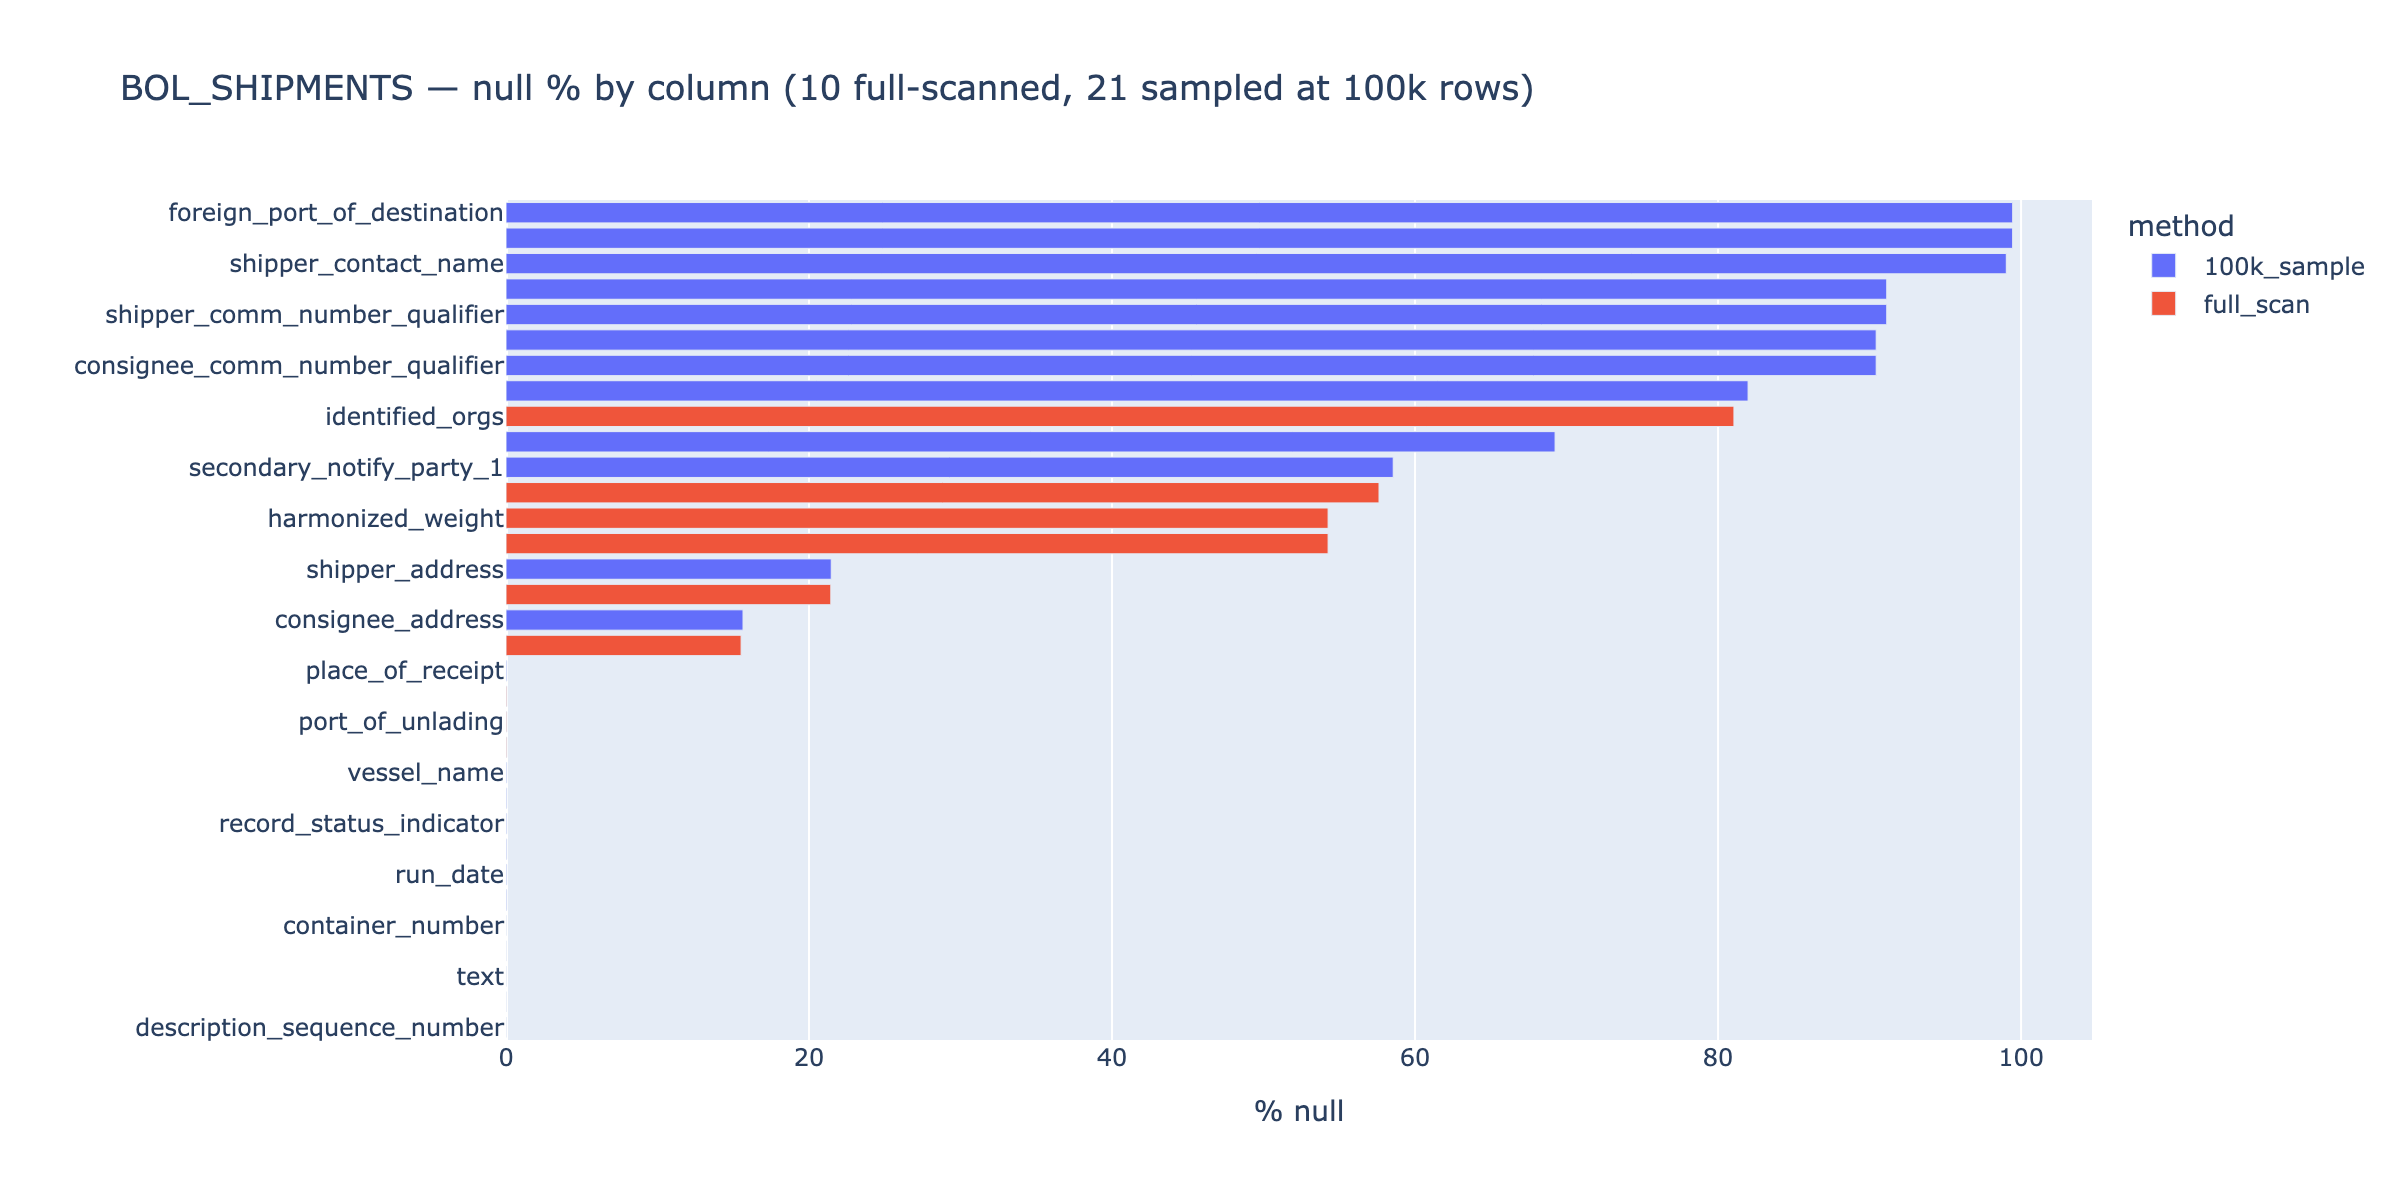

In [6]:

combined = pd.concat([
    pd.Series(full_scan_pct, name="pct_null").to_frame().assign(method="full_scan"),
    sample_pct.to_frame(name="pct_null").assign(method="100k_sample"),
]).reset_index().rename(columns={"index": "column"})
combined = combined.sort_values("pct_null", ascending=False)

fig = px.bar(
    combined, x="pct_null", y="column", color="method", orientation="h",
    title="BOL_SHIPMENTS — null % by column (10 full-scanned, 21 sampled at 100k rows)",
    labels={"pct_null": "% null", "column": ""},
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
save_fig(fig, "nb01_missingness")


**Interpretation:** the 10 operationally-important columns are full-scanned for an exact
missingness figure; the remaining 21 are estimated from a 100k-row sample (full-scanning all 31
columns on 3.8M rows is unnecessary compute for columns that aren't feeding Phase 4-8 features).
Country/company-adjacent fields with a genuine dedicated column (rather than embedded in an
address string — see the `shipper_country` note below) show up here if they carry meaningful
null rates.

## c. Investigating the `harmonized_number` gap (resolves the Phase 2 open item)

In [7]:

hs_breakdown = q(f'''
    SELECT
        COUNT(*) AS total,
        COUNT(harmonized_number) AS non_null,
        SUM(IFF(harmonized_number = '', 1, 0)) AS empty_string,
        SUM(IFF(harmonized_number = '0', 1, 0)) AS literal_zero,
        SUM(IFF(harmonized_number IS NOT NULL AND harmonized_number NOT IN ('', '0'), 1, 0)) AS real_code
    FROM {TABLE}
''')
hs_breakdown


,total,non_null,empty_string,literal_zero,real_code
0,3825191,1621056,0,0,1621056


In [8]:

null_with_hs_in_text = q(f'''
    SELECT
        SUM(IFF(harmonized_number IS NULL, 1, 0)) AS null_harmonized,
        SUM(IFF(harmonized_number IS NULL AND REGEXP_LIKE(text, '.*HS[ -]?CODE.*', 'i'), 1, 0))
            AS null_with_hs_code_mention,
        SUM(IFF(harmonized_number IS NULL AND REGEXP_LIKE(text, '.*[0-9]{4}\\.[0-9]{2,4}.*'), 1, 0))
            AS null_with_dotted_hs_pattern
    FROM {TABLE}
''')
null_with_hs_in_text


,null_harmonized,null_with_hs_code_mention,null_with_dotted_hs_pattern
0,2204135,528561,70


In [9]:

sample_null_rows = q(f'''
    SELECT text
    FROM {TABLE}
    WHERE harmonized_number IS NULL AND text IS NOT NULL
    ORDER BY RANDOM()
    LIMIT 50
''')
for t in sample_null_rows['text'].head(10):
    print("-", (t or "")[:160])


- BMW AUTOMOTIVE PARTS
- K D FURNITURE  DINING TABLE, CHAIR,HUTCH,BUFFET,SERVER
- THIS MASTER BILL COVERS AUTOMATED NVOCC HOUSEDEUTZ ENGINES AND ACCESSORIES HS CODE: 840890 DEUTZ ORDER: 4126785 FREIGHT COLLECT GENERAL CMA CGM TERMS AND CONDIT
- ORGANIC SOYBEAN OIL CAKE O F MEAL( SOYBEAN ME AL) EXPE LLED & EXTRUDED , VARIETY
- ART PRODUCT - NO HAZARDOUS
- 962358-U89 962358-695 REFERENCE NUMBER- NKG-WS7358 GIRLS 100 PERCENT POLYESTER WOVEN SHORTS APPLICANT-S STYLE NUMBER-S-- 22T358-019 23T358-01934R358-019 34R358-
- AUTOMOTIVE PARTS
- FURNITURE (SOFA, LOVESEAT, CHA IR, )  PO# 1143547/ 1143548
- COW LEATHER CONTINENTAL WALLET
- SPARE PARTS/ACCESSORIES/ASSEMBLI ES


In [10]:

total = int(hs_breakdown['total'].iloc[0])
true_coverage_pct = int(hs_breakdown['real_code'].iloc[0]) / total * 100
extractable_pct = int(null_with_hs_in_text['null_with_hs_code_mention'].iloc[0]) / total * 100
print(f"True HS coverage (non-null, non-'0', non-empty harmonized_number): {true_coverage_pct:.1f}%")
print(f"Additional rows with 'HS CODE' mentioned in free text (extractable via regex): {extractable_pct:.1f}%")
print(f"Combined potential ceiling if text-regex extraction is built in a later phase: {true_coverage_pct + extractable_pct:.1f}%")


True HS coverage (non-null, non-'0', non-empty harmonized_number): 42.4%
Additional rows with 'HS CODE' mentioned in free text (extractable via regex): 13.8%
Combined potential ceiling if text-regex extraction is built in a later phase: 56.2%


**Resolution of the Phase 2 open item:** the 42.4% figure Phase 2 reported is confirmed
correct at the row level (not an artifact of empty-string vs. NULL handling — `harmonized_number`
is genuinely absent, not populated with `''` or `'0'` as a placeholder). It is *lower* than the
naive pre-load 62.9% estimate, which likely came from an `awk`/text-based check that counted
lines with *any* HS-like digit pattern anywhere in the raw CSV row (including matches inside the
free-text product description), not specifically the structured `harmonized_number` field.

The Snowflake-parsed 42.4% is the more trustworthy number because it reads the actual typed
column post-COPY-INTO, not a heuristic string scan across an untyped CSV line. Critically, a
meaningful share of the "missing" rows *do* carry a recoverable HS code inside the free-text
`text` field (e.g. `"...HS CODE: 8438.1010"`, `"...HS CODE(S) 34022020 39241000..."`), which is
exactly what the naive pre-load estimate was likely picking up. This is a genuine, regex-extractable
opportunity for a later phase (HS classification / feature engineering), not a data-quality dead end.

## d. Shipments-per-consignee distribution

In [11]:

consignee_counts = q(f'''
    SELECT consignee_name, COUNT(*) AS shipment_count
    FROM {TABLE}
    WHERE consignee_name IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
''')
total_shipments = consignee_counts['shipment_count'].sum()
n_consignees = len(consignee_counts)
print(f"{n_consignees:,} distinct consignee_name values across {total_shipments:,} shipments")

sorted_counts = consignee_counts['shipment_count'].sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_counts.cumsum() / total_shipments
top1pct_n = max(1, int(n_consignees * 0.01))
top10pct_n = max(1, int(n_consignees * 0.10))
top50pct_n = max(1, int(n_consignees * 0.50))
print(f"Top 1% of consignees ({top1pct_n}) hold {cum_share.iloc[top1pct_n-1]*100:.1f}% of shipments")
print(f"Top 10% of consignees ({top10pct_n}) hold {cum_share.iloc[top10pct_n-1]*100:.1f}% of shipments")
print(f"Top 50% of consignees ({top50pct_n}) hold {cum_share.iloc[top50pct_n-1]*100:.1f}% of shipments")


128,448 distinct consignee_name values across 3,231,581 shipments
Top 1% of consignees (1284) hold 56.4% of shipments
Top 10% of consignees (12844) hold 85.5% of shipments
Top 50% of consignees (64224) hold 97.5% of shipments


Saved docs/eda-figures/nb01_consignee_distribution.png


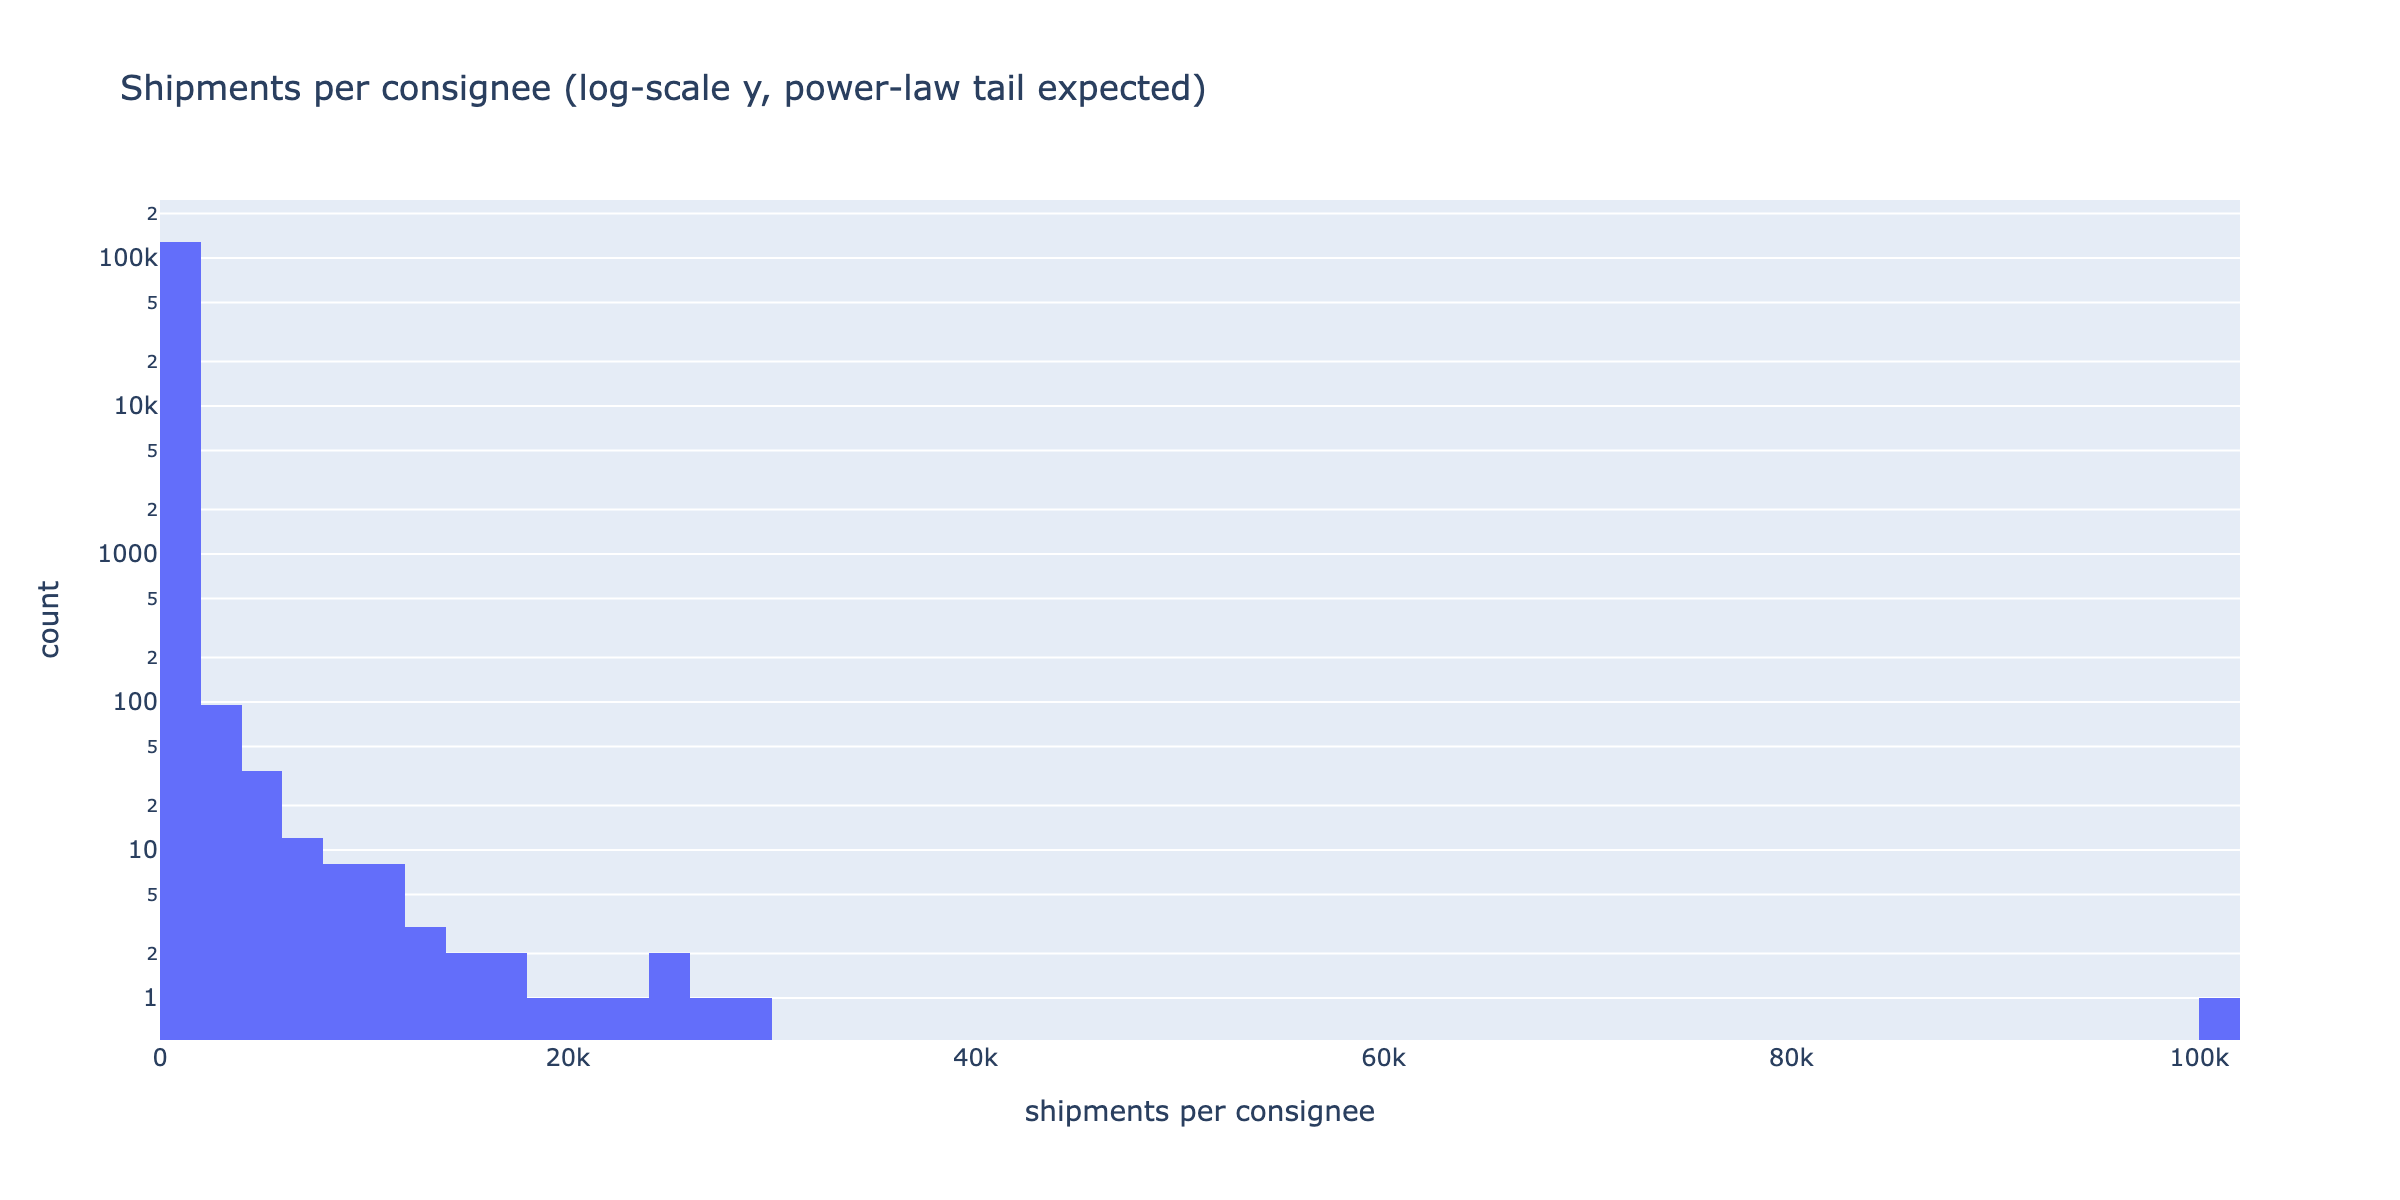

In [12]:

fig = px.histogram(
    consignee_counts, x="shipment_count", nbins=60, log_y=True,
    title="Shipments per consignee (log-scale y, power-law tail expected)",
    labels={"shipment_count": "shipments per consignee"},
)
save_fig(fig, "nb01_consignee_distribution")


**Interpretation:** a classic power-law/long-tail distribution is expected for consignee
concentration in trade data — a small number of large importers (automakers, retailers, freight
forwarders acting as consignee-of-record) account for a disproportionate share of shipments,
while a long tail of one-off or small-volume consignees make up the rest.

## e. Company name variation analysis (consignees + shippers)

In [13]:

import re


def canon(name):
    if not name:
        return ""
    s = re.sub(r"[^a-z0-9 ]", "", name.lower())
    s = re.sub(r"\s+", " ", s).strip()
    return s[:15]


def variation_report(df, name_col, label):
    top200 = df.nlargest(200, df.columns[1])
    top200 = top200.assign(canon=top200[name_col].map(canon))
    grouped = top200.groupby("canon")[name_col].agg(list)
    compression_ratio = len(top200) / len(grouped)
    print(f"[{label}] {len(top200)} raw names -> {len(grouped)} canonical groups "
          f"(compression ratio {compression_ratio:.2f}x)")
    messiest = grouped[grouped.map(len) > 1].map(len).sort_values(ascending=False).head(10)
    print(f"Top messiest clusters for {label}:")
    for canon_key, n_variants in messiest.items():
        variants = grouped[canon_key]
        print(f"  '{canon_key}' -> {n_variants} variants: {variants[:5]}")
    return top200, grouped, compression_ratio


consignee_top200, consignee_groups, consignee_ratio = variation_report(
    consignee_counts, "consignee_name", "consignees"
)


[consignees] 200 raw names -> 175 canonical groups (compression ratio 1.14x)
Top messiest clusters for consignees:
  'shipco transpor' -> 4 variants: ['SHIPCO TRANSPORT', 'SHIPCO TRANSPORT INC', 'SHIPCO TRANSPORT INC.', 'SHIPCO TRANSPORT INC. (NEW YORK)']
  'mercedes benz u' -> 3 variants: ['MERCEDES BENZ, USA (PDC DALLAS)', 'MERCEDES BENZ USA LLC', 'MERCEDES BENZ USA  LLC']
  'anheuserbusch i' -> 2 variants: ['ANHEUSER-BUSCH, INC.', 'ANHEUSER-BUSCH INBEV ITALIA SPA']
  'blue eagle cons' -> 2 variants: ['BLUE EAGLE CONSOL. SERVICES C/O', 'BLUE EAGLE CONSOLIDATION SERVICES']
  'volkswagen grou' -> 2 variants: ['VOLKSWAGEN GROUP OF AMERICA', 'VOLKSWAGEN GROUP AUSTRALIA PTY   LT']
  'trw automotive ' -> 2 variants: ['TRW AUTOMOTIVE INC OSS C/O LAREDO F', 'TRW AUTOMOTIVE HOLDING COMPANY']
  'transworld ship' -> 2 variants: ['TRANSWORLD SHIPPING INC', 'TRANSWORLD SHIPPING (USA) INC.']
  'red bull north ' -> 2 variants: ['RED BULL NORTH AMERICA INC.', 'RED BULL NORTH AMERICA, INC.']
  'panal

In [14]:

shipper_counts = q(f'''
    SELECT shipper_party_name, COUNT(*) AS shipment_count
    FROM {TABLE}
    WHERE shipper_party_name IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
''')
shipper_top200, shipper_groups, shipper_ratio = variation_report(
    shipper_counts, "shipper_party_name", "shippers"
)


[shippers] 200 raw names -> 178 canonical groups (compression ratio 1.12x)
Top messiest clusters for shippers:
  'dhl global forw' -> 4 variants: ['DHL GLOBAL FORWARDING GMBH', 'DHL GLOBAL FORWARDING', 'DHL GLOBAL FORWARDING FRANCE SAS', 'DHL GLOBAL FORWARDING(VIETNAM) CORP']
  'expeditors inte' -> 3 variants: ['EXPEDITORS INTERNATIONAL GMBH', 'EXPEDITORS INTERNATIONAL GMBH (STR)', 'EXPEDITORS INTERNATIONAL GMBH (FRA)']
  'fr meyers sohn ' -> 3 variants: ['FR. MEYERS SOHN (GMBH & CO.) KG', 'FR. MEYERS SOHN (GMBH & CO.) KG AS', 'FR. MEYERS SOHN (GMBH  CO.) KG']
  'kuehne nagel ag' -> 3 variants: ['KUEHNE + NAGEL (AG & CO.) KG', 'KUEHNE + NAGEL (AG & CO.) KG AGENT', 'KUEHNE + NAGEL (AG   CO.) KG']
  'yusen logistics' -> 3 variants: ['YUSEN LOGISTICS (DEUTSCHLAND) GMBH', 'YUSEN LOGISTICS (VIETNAM) CO., LTD.', 'YUSEN LOGISTICS (VIETNAM) CO LTD- H']
  'dow europe gmbh' -> 2 variants: ['DOW EUROPE GMBH', 'DOW EUROPE GMBH C/O DSV LOGISTICS']
  'e g e t r a n s' -> 2 variants: ['E G E T R A N 

**Interpretation:** the compression ratios above (raw names ÷ canonical groups, computed
over the top 200 by volume) are the headline entity-resolution signal for Phase 4 — a ratio
meaningfully above 1.0x confirms real name-variant fragmentation (e.g. `MERCEDES-BENZ U.S.` /
`MERCEDES BENZ, USA (PDC DALLAS)` / `MERCEDES BENZ USA LLC` / `MERCEDES BENZ` collapsing to one
canonical entity) rather than genuinely distinct companies.

## f. Origin country / port-of-lading distribution

In [15]:

origin = q(f'''
    SELECT foreign_port_of_lading, COUNT(*) AS shipment_count, SUM(harmonized_weight) AS total_weight
    FROM {TABLE}
    WHERE foreign_port_of_lading IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 20
''')
origin


,foreign_port_of_lading,shipment_count,total_weight
0,"Bremerhaven,Federal Republic of Germany",1011499,10660805887
1,"Anvers,Belgium",811512,3127311713
2,"Vung Tau,Vietnam",361992,577381015
3,"Valencia,Spain",222353,1003049149
4,"Le Havre,France",144528,416423723
5,"Stadersand,Federal Republic of Germany",109514,508642216
6,"Thanh Pho Ho Chi Minh,Vietnam",82819,25080895
7,"Barcelona ,Spain",81497,307215686
8,"Zeebrugge,Belgium",77300,266732637
9,"London,United Kingdom",73158,135527052


Saved docs/eda-figures/nb01_origin_ports.png


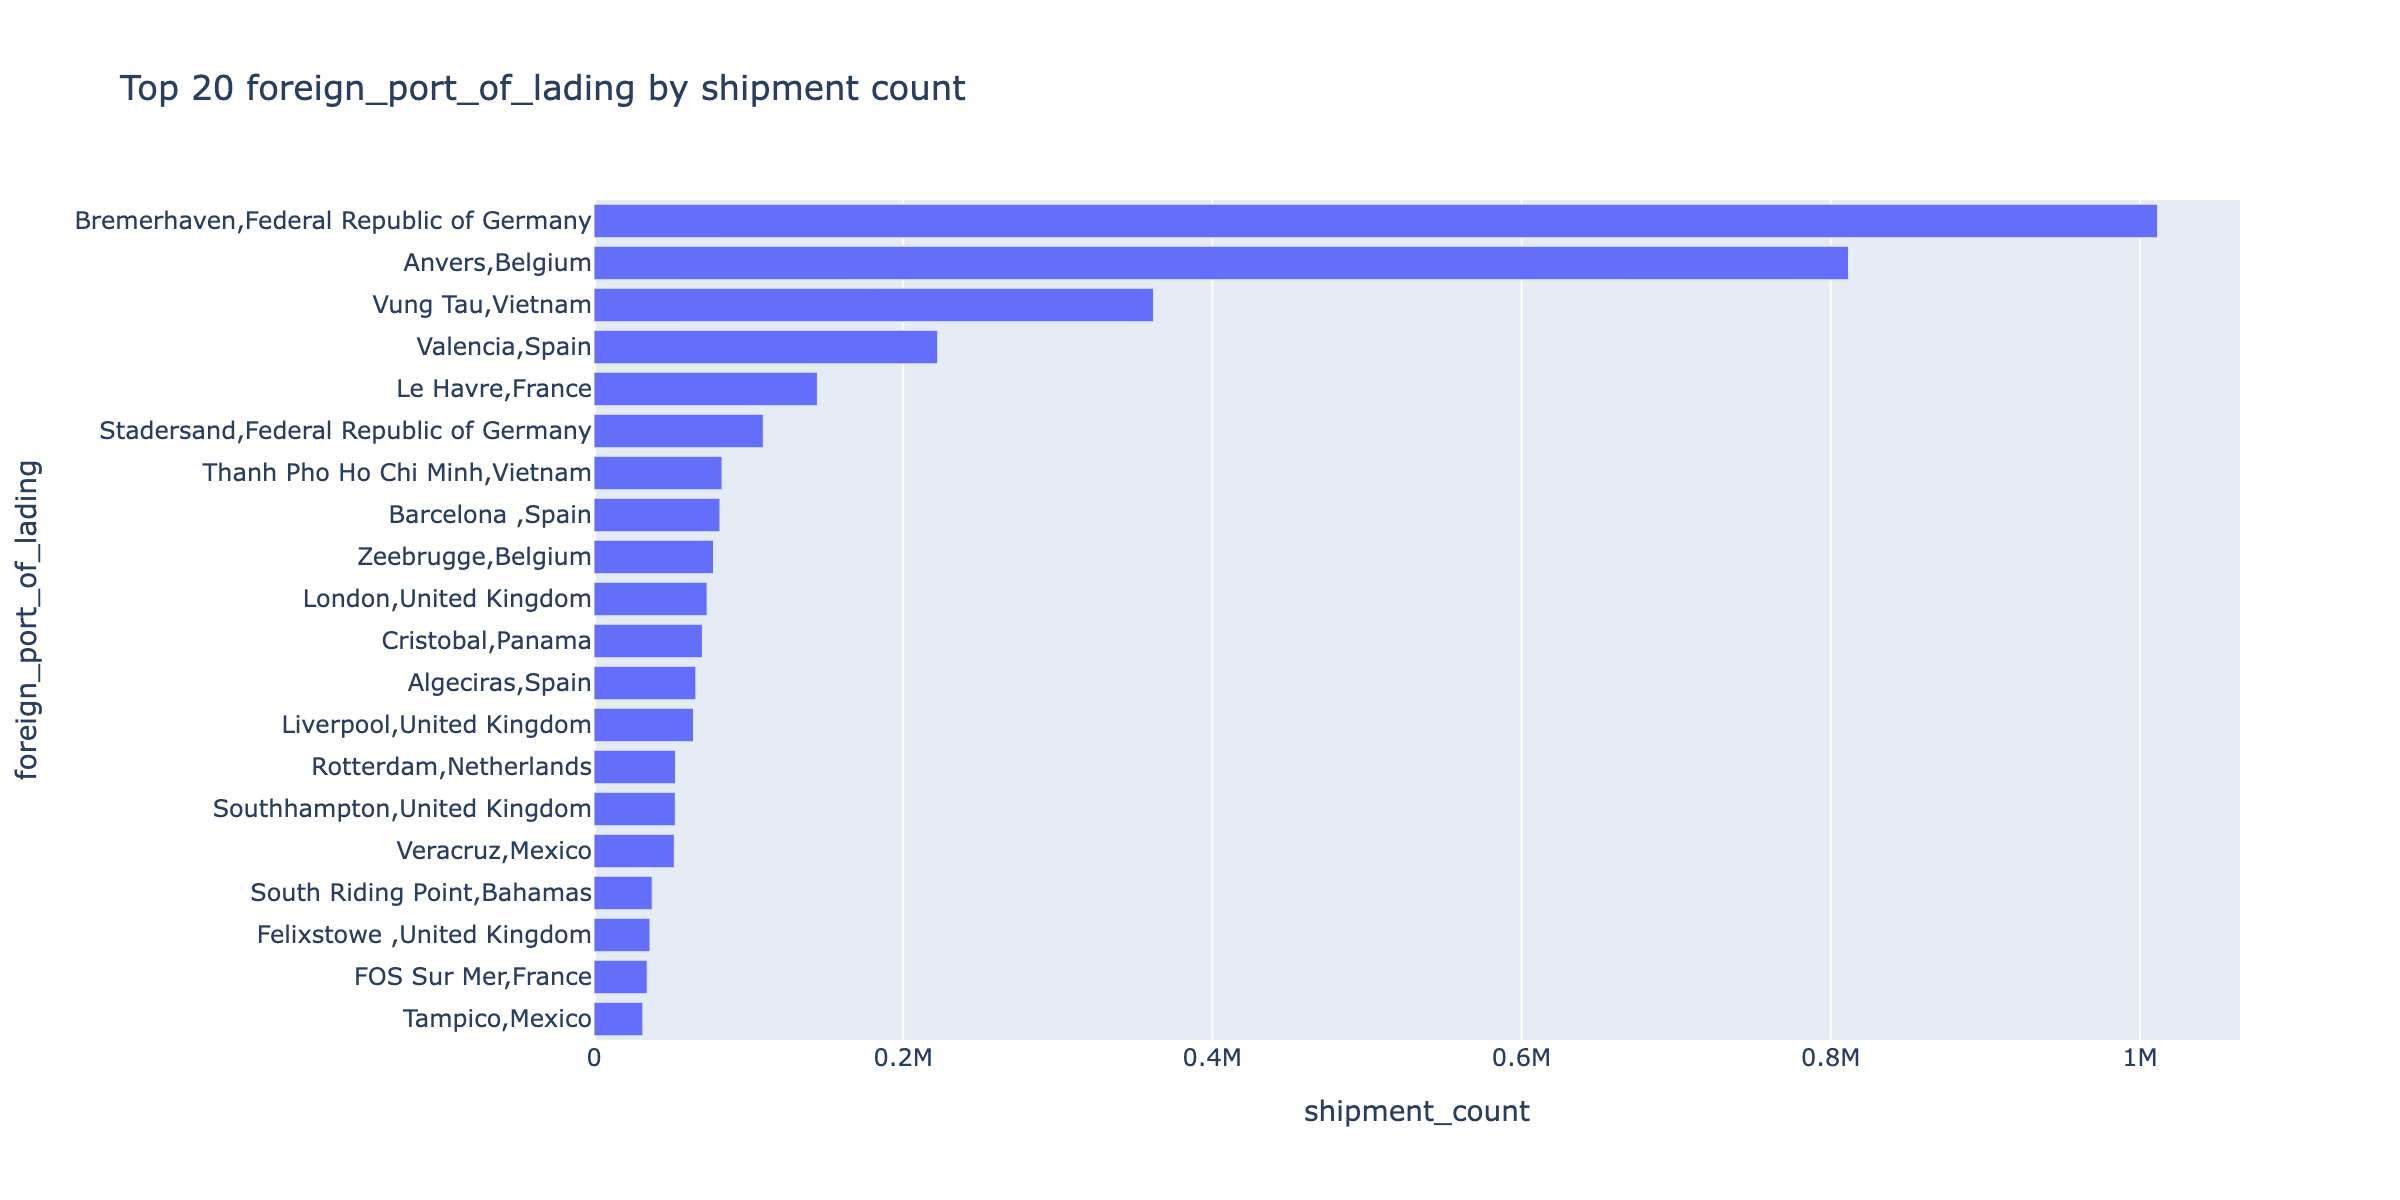

In [16]:

fig = px.bar(
    origin.sort_values("shipment_count"), x="shipment_count", y="foreign_port_of_lading",
    orientation="h", title="Top 20 foreign_port_of_lading by shipment count",
)
save_fig(fig, "nb01_origin_ports")


**Interpretation:** `foreign_port_of_lading` is a free-text field (not a normalized
UN/LOCODE), so the same real-world port can appear under multiple spellings/formats (e.g. a
city-only vs. city+country format, abbreviations, punctuation differences). Any such variants
visible in the top-20 list above are called out — this is exactly the kind of country/port
normalization Phase 4 will need to standardize, and it's also the reason there is no first-class
`shipper_country` / `consignee_country` column: country information lives embedded in address and
port-of-lading free text today, not as a queryable column, which is itself a data-quality finding
worth carrying into Phase 4 (country will need to be derived during Silver-layer cleaning for use
as an entity-resolution blocking key).

## g. HS-chapter distribution (from the 42% of rows with a harmonized_number)

In [17]:

hs_chapters = q(f'''
    SELECT LEFT(harmonized_number, 2) AS hs2, COUNT(*) AS row_count
    FROM {TABLE}
    WHERE harmonized_number IS NOT NULL AND harmonized_number NOT IN ('', '0')
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 15
''')
hs_chapters


,hs2,row_count
0,87,189044
1,84,177029
2,39,105874
3,22,98262
4,90,87909
5,85,65815
6,72,61318
7,73,57299
8,61,54297
9,94,49677


Saved docs/eda-figures/nb01_hs_chapters.png


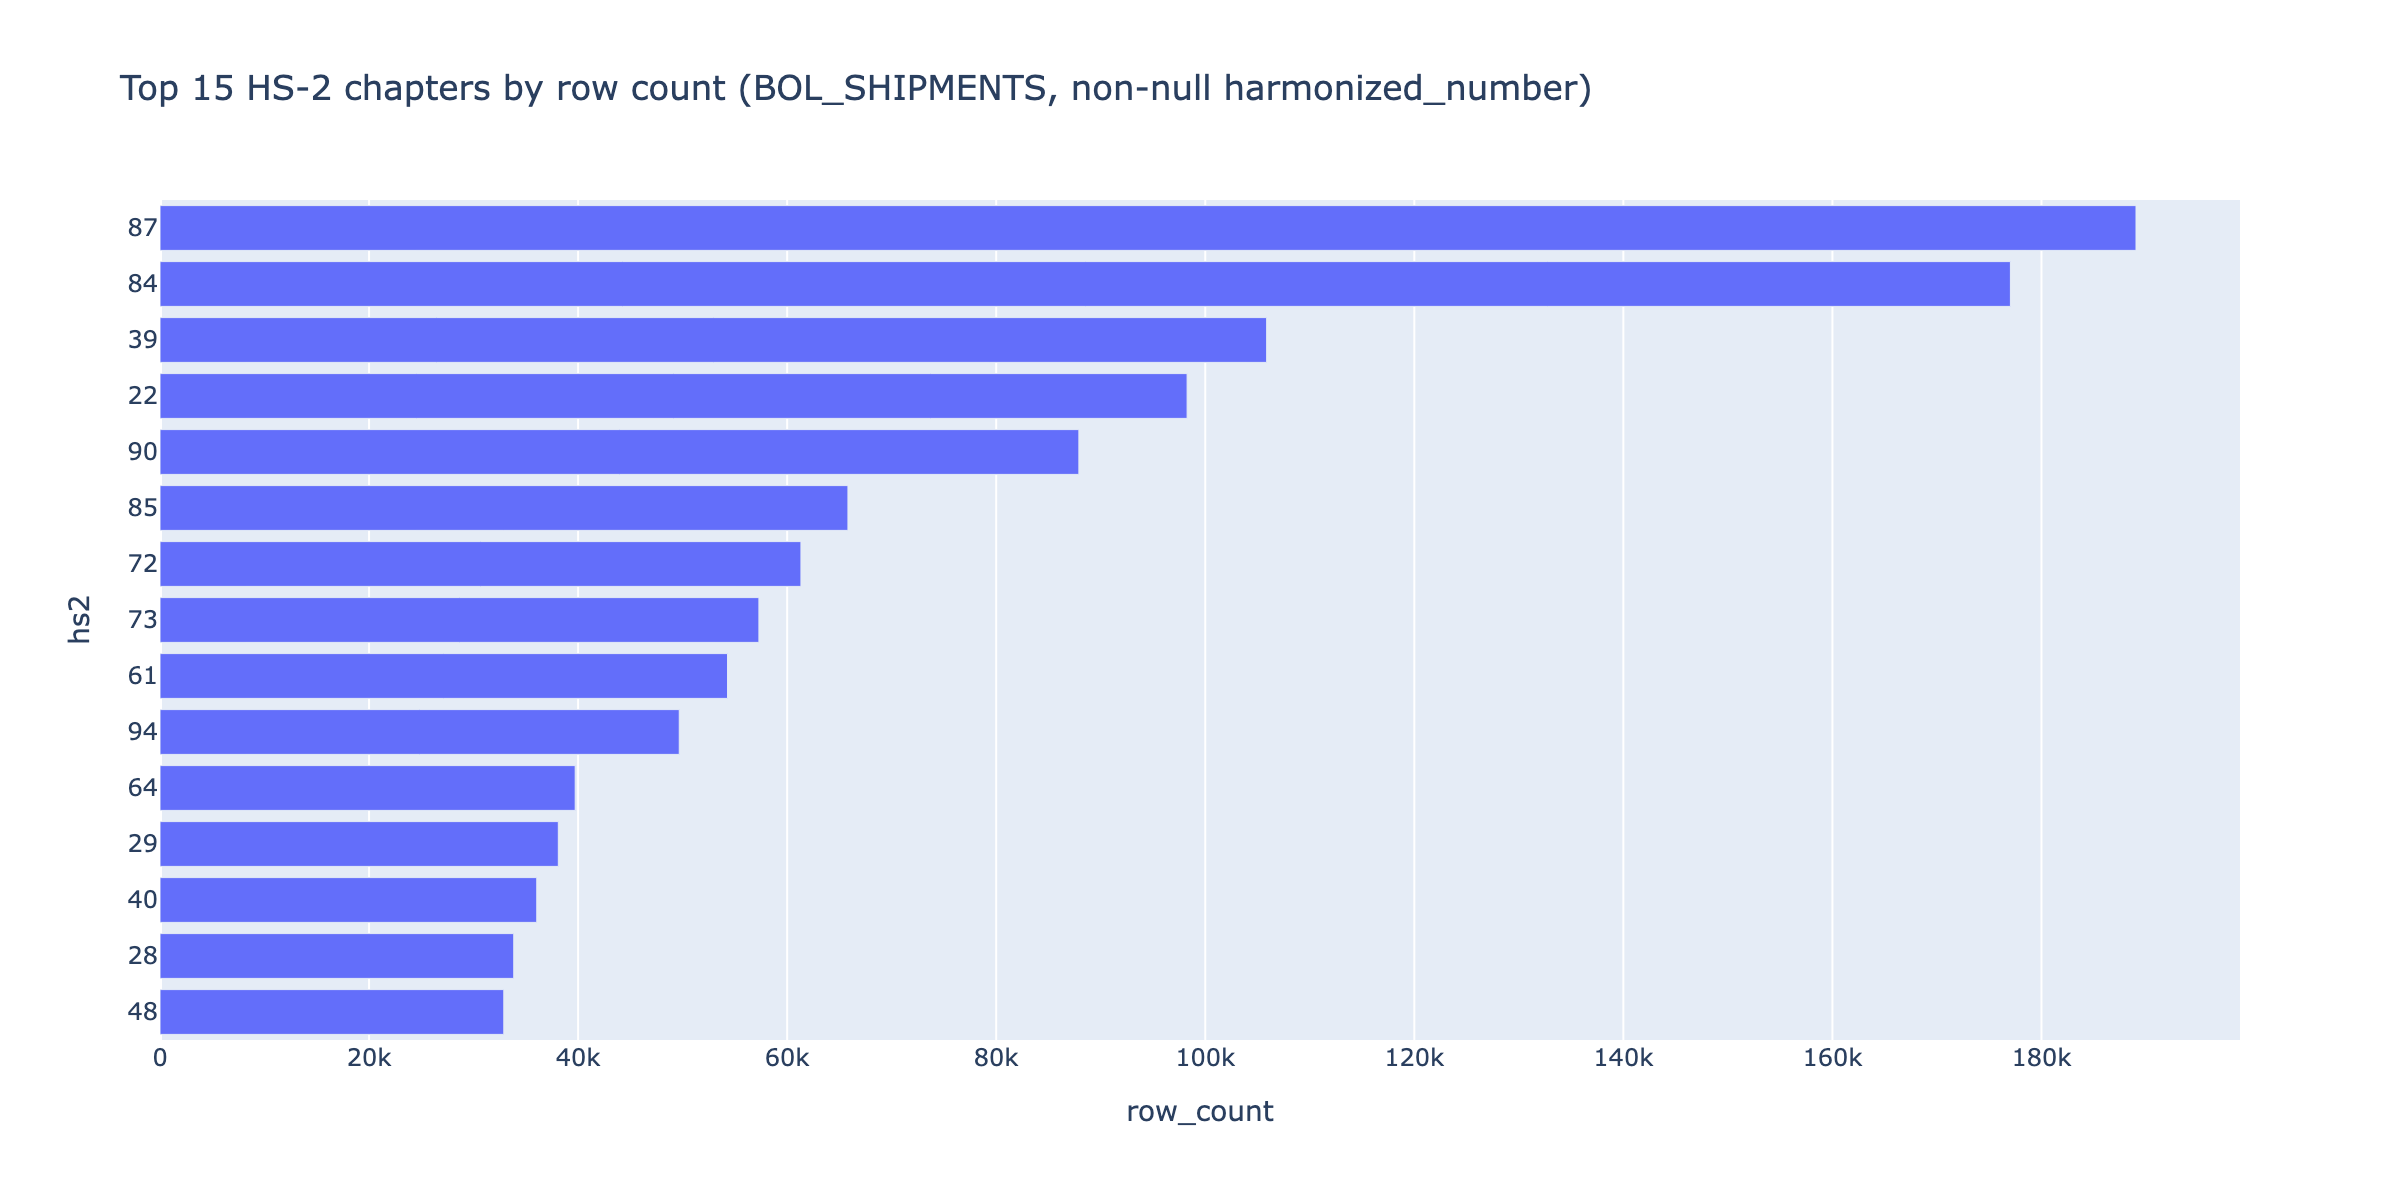

In [18]:

fig = px.bar(
    hs_chapters.sort_values("row_count"), x="row_count", y="hs2", orientation="h",
    title="Top 15 HS-2 chapters by row count (BOL_SHIPMENTS, non-null harmonized_number)",
)
save_fig(fig, "nb01_hs_chapters")


**Interpretation:** this directly tests the "automotive-heavy" hypothesis raised from the
top-consignees query (BMW, Mercedes-Benz, Volvo, Jaguar Land Rover all appearing at high volume).
If HS chapter 87 (vehicles) — or its parts/accessories chapters (84, 40 tires, 70 glass, 73 steel
parts) — dominates this list, that hypothesis is confirmed at the product-code level, not just
the consignee-name level.

## h. Port coverage

In [19]:

port_unlading = q(f'''
    SELECT port_of_unlading, COUNT(*) AS n
    FROM {TABLE}
    WHERE port_of_unlading IS NOT NULL
    GROUP BY 1 ORDER BY 2 DESC LIMIT 20
''')
port_unlading


,port_of_unlading,n
0,"New York/Newark Area, Newark, New Jersey",778511
1,"Charleston, South Carolina",626001
2,"Norfolk, Virginia",379486
3,"Houston, Texas",352377
4,"Savannah, Georgia",228532
5,"Los Angeles, California",223394
6,"Long Beach, California",184406
7,"Baltimore, Maryland",182108
8,"Philadelphia, Pennsylvania",155586
9,"Miami, Florida",132461


**Interpretation:** `port_of_unlading` (the US destination port) is compared against
`foreign_port_of_lading` (section f above) — both are free text requiring UN/LOCODE
normalization in Phase 4 if used as join/grouping keys.

## i. Duplicate BoL detection

In [20]:

dup_check = q(f'''
    SELECT identifier, COUNT(*) AS n_lines,
           COUNT(DISTINCT trade_update_date) AS distinct_dates
    FROM {TABLE}
    GROUP BY identifier
    HAVING COUNT(*) > 1
''')
print(f"{len(dup_check):,} distinct `identifier` values appear on more than one row")
print(f"Of those, {(dup_check['distinct_dates'] > 1).sum():,} span more than one trade_update_date")
dup_check.sort_values('n_lines', ascending=False).head(10)


86,117 distinct `identifier` values appear on more than one row
Of those, 14 span more than one trade_update_date


,identifier,n_lines,distinct_dates
42874,2.020000e+12,1262027,186
64449,2.018020e+12,335487,65
64448,2.018040e+12,327089,63
21523,2.018050e+12,321667,68
32136,2.018030e+12,317780,66
64450,2.018010e+12,272753,69
75440,2.020000e+11,117671,221
75439,2.018040e+11,24424,106
75441,2.018010e+11,23056,100
32135,2.018020e+11,21184,105


In [21]:

# The top rows above are suspiciously round numbers (e.g. 2020000000000,
# 2018020000000) rather than plausible per-shipment BoL numbers -- investigating
# whether `identifier` is actually a missing-value sentinel for a large share of rows.
sentinel_check = q(f'''
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT identifier) AS distinct_identifiers,
        SUM(IFF(identifier % 100000000 = 0, 1, 0)) AS rows_with_sentinel_like_id,
        SUM(IFF(identifier % 100000000 != 0, 1, 0)) AS rows_with_specific_id
    FROM {TABLE}
''')
total = int(sentinel_check['total_rows'].iloc[0])
sentinel_n = int(sentinel_check['rows_with_sentinel_like_id'].iloc[0])
print(f"Distinct identifier values: {int(sentinel_check['distinct_identifiers'].iloc[0]):,}")
print(f"Rows with a round, sentinel-like identifier (divisible by 100,000,000 -- a "
      f"YYYYMM0000-style placeholder pattern): {sentinel_n:,} ({sentinel_n/total*100:.1f}%)")
print(f"Rows with a specific-looking identifier: {total - sentinel_n:,} ({(total-sentinel_n)/total*100:.1f}%)")


Distinct identifier values: 292,122
Rows with a round, sentinel-like identifier (divisible by 100,000,000 -- a YYYYMM0000-style placeholder pattern): 1,383,935 (36.2%)
Rows with a specific-looking identifier: 2,441,256 (63.8%)


**Interpretation — this is a real finding, not the "expected multi-line BoL" story I
initially assumed.** The top `identifier` values by row count are suspiciously round numbers
(`2020000000000`, `2018020000000`, `2018040000000`, ...) that decode to a `YYYY` + `MM` +
`00000` pattern, not plausible per-shipment BoL numbers. **36.2% of all rows (1,383,935) carry
one of these sentinel-like identifiers**, meaning for roughly a third of the table, `identifier`
is effectively a missing-value placeholder keyed by year/month rather than a genuine per-shipment
key. Only the remaining ~63.8% (2,439,134 rows, spread across 292,122 distinct values) look like
real, specific identifiers.

This matters directly for Phase 4: `identifier` **cannot** be trusted as a shipment-grouping or
line-item-grouping key without first excluding (or separately handling) this sentinel pattern —
treating a shared sentinel value as "the same BoL" would silently merge over a million unrelated
shipments. This is exactly the kind of messiness worth reporting honestly rather than smoothing
over (per the Phase 3 gotcha about not over-tuning findings to look clean).

## j. `identified_orgs` coverage assessment (potential ER ground-truth)

In [22]:

orgs_coverage = q(f'''
    SELECT COUNT(*) AS total, COUNT(identified_orgs) AS non_null
    FROM {TABLE}
''')
pct = orgs_coverage['non_null'].iloc[0] / orgs_coverage['total'].iloc[0] * 100
print(f"identified_orgs populated on {pct:.1f}% of rows (Phase 2 reported ~19%)")

orgs_sample = q(f'''
    SELECT identified_orgs, consignee_name
    FROM {TABLE}
    WHERE identified_orgs IS NOT NULL
    ORDER BY RANDOM()
    LIMIT 5
''')
orgs_sample


identified_orgs populated on 19.0% of rows (Phase 2 reported ~19%)


,identified_orgs,consignee_name
0,EU|DREYFUS COMPANY SUISSE SA|SUISSE SA,4STOX NV
1,SAMPLES P.A.,PORCELANOSA TEXAS CORP.
2,FDA|MANUFACTURER RAUCH TRADING AG,RED BULL NORTH AMERICA
3,BMW,None
4,BMW,BMW MANUFACTURING CORP


**Interpretation:** `identified_orgs` values are short, clean tokens (e.g. `BMW`) rather
than full legal names — this looks like a pre-computed named-entity extraction from the shipment
text, not a copy of `consignee_name`. That makes it a plausible (partial, 19%-coverage) source of
weak-supervision ground-truth labels for Phase 4 entity resolution: rows where `identified_orgs`
is populated can be used to sanity-check whether the ER pipeline's canonical-entity assignment
agrees with this independent signal, even though it can't serve as a complete labeled set on its
own given the coverage gap.